In [1]:
import argparse
import os
from typing import Dict, List, Tuple

import torch
import matplotlib.pyplot as plt
import numpy as np
import einops

from models.modeling_encoders import AutoEncoder
from models.tarsier2.dataset.utils import format_one_sample

import shared.utils as su
from evals_tarsier2.compute_video_attentions import *

VIDEO_EXTENSIONS = {"mp4", "avi", "mov", "mkv", "webm"}

Failed to import Qwen2_5_VLModel, Qwen2_5_VLForConditionalGeneration.


### Load model

In [2]:
# Load model
# model_path = "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115/"
# model_name = "Tarsier 2"
model_path = "/work/piyush/pretrained_checkpoints/TARA/"
model_name = "TARA"
# NOTE: need to sdpa attention to get attention weights (Flash Attention does not return weights)
encoder = AutoEncoder.from_pretrained(
    model_path,
    device_map="auto",
    attn_implementation="eager",
    dtype=torch.bfloat16,
    base_config_name="nframes=4.yaml"
)
su.misc.num_params(encoder.model)

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading EncoderForTarsier2 from /work/piyush/pretrained_checkpoints/TARA/


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

::: Number of total parameters in Tarsier2ForConditionalGeneration: 8291.376M


In [3]:
# Number of layers and heads
L = len(encoder.model.language_model.model.layers)
H = encoder.model.language_model.model.layers[0].self_attn.num_heads
L, H

(28, 28)

### Load video

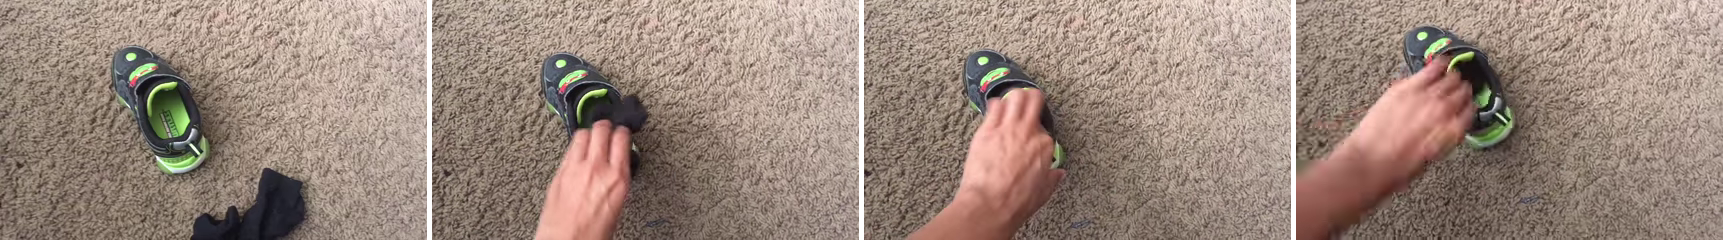

In [64]:
# video_path = "../assets/demo.mp4"
# video_path = "/scratch/shared/beegfs/piyush/datasets/SSv2/20bn-something-something-v2/111121.webm"
data_dir = "/scratch/shared/beegfs/piyush/datasets/SSv2"
# video_path = f"{data_dir}/20bn-something-something-v2/111196.webm"
# video_path = f"{data_dir}/20bn-something-something-v2/111169.webm"
video_path = f"{data_dir}/20bn-something-something-v2/111141.webm"


# video_path = "../assets/folding_paper.mp4"
assert os.path.exists(video_path)

# Visualize frames
su.visualize.concat_images_with_border(su.video.load_frames_linspace(video_path, n=4))

### Visualize attentions

In [65]:
# Prepare inputs
prompt = resolve_prompt(encoder, video_path, None)
model_inputs = build_model_inputs(encoder, video_path, prompt)
m = build_visual_index_map(model_inputs, encoder)
print(f"Tokenized sequence length S = {model_inputs['input_ids'].shape[-1]}")

# embedding, attention_lhss = run_embedding_and_attention(
#     encoder,
#     model_inputs,
#     save_dtype=dtype_from_name("float32"),
# )

# embedding.shape, attention_lhss.shape

Tokenized sequence length S = 571


In [66]:
embedding, attention_lhss, hidden_states_lsd = run_embedding_and_attention(
    encoder,
    model_inputs,
    save_dtype=torch.float32,
)
print(embedding.shape, attention_lhss.shape, hidden_states_lsd.shape)

torch.Size([3584]) torch.Size([28, 28, 571, 571]) torch.Size([28, 571, 3584])


In [67]:
# D = hidden_states_lsd.shape[-1]
# for i in range(L):
#     plt.plot(hidden_states_lsd[:, 0][i].abs())
#     plt.title(i)
#     plt.show()

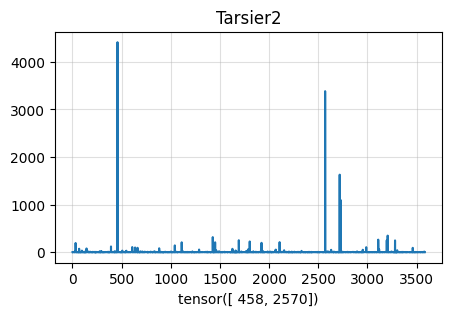

In [68]:
x = hidden_states_lsd.mean(dim=0)[0].abs()

plt.figure(figsize=(5, 3))
plt.plot(x)
plt.grid(alpha=0.4)
# plt.title(torch.where(x > 2000)[0]);
plt.title("Tarsier2");
plt.xlabel(torch.where(x > 2000)[0]);

In [69]:
D_sink = [458, 2570]
D_sink

[458, 2570]

In [70]:
def compute_sink_score(x, d_sink: list = D_sink):
    if len(x.shape) == 1:
        x = x.unsqueeze(0)
    norm = torch.linalg.norm(x, dim=-1, keepdims=True) / np.sqrt(x.shape[-1])
    return (x[:, d_sink] / norm).abs().max(dim=-1).values


x = torch.randn(3584)
compute_sink_score(x)

tensor([0.7480])

torch.Size([28, 571])
torch.Size([28, 540])


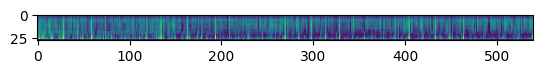

In [71]:
ls = einops.rearrange(compute_sink_score(einops.rearrange(hidden_states_lsd, "l s d -> (l s) d")), "(l s) -> l s", l=len(hidden_states_lsd))
print(ls.shape)

vs = m['visual_start']
ve = m['visual_end_exclusive']
ls_v = ls[:, vs:ve]
print(ls_v.shape)

plt.imshow(ls_v)

Number of visual sink tokens: 94


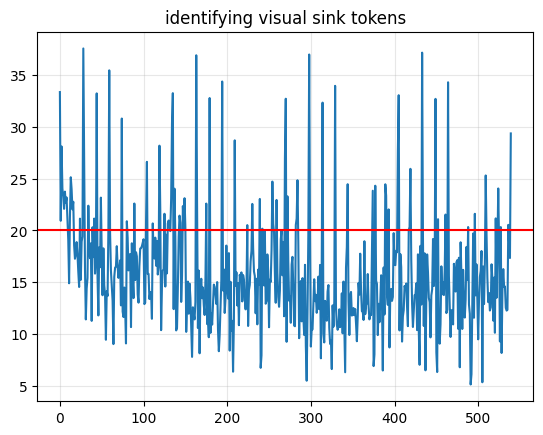

In [85]:
x = ls_v.mean(dim=0)

tau = 20
plt.plot(x);
plt.axhline(y=tau, c='red')
plt.title("identifying visual sink tokens")
plt.grid(alpha=0.3)

visual_sink_tokens = torch.where(x >= tau)[0]
print("Number of visual sink tokens:", len(visual_sink_tokens))

In [79]:
vs, ve = m["visual_start"], m["visual_end_exclusive"]
a_vis = attention_lhss[:, :, -1, vs:ve].clone()
print(a_vis.shape)

# Set the visual sink token attentions to 0
suppress_sinks = True
if suppress_sinks:
    print("Setting visual attention sinks to 0")
    a_vis[:, :, visual_sink_tokens] = 0.

# from your mapping dict m
T = m["T_llm"]      # temporal tokens
H_p = m["H_llm"]    # num_h_patches
W_p = m["W_llm"]    # num_w_patches

# sanity
assert a_vis.shape[-1] == T * H_p * W_p, (a_vis.shape, T, H_p, W_p)

# [L, H, N_vis] -> [L, H, T, H_p, W_p]
a_vis_thw = a_vis.reshape(a_vis.shape[0], a_vis.shape[1], T, H_p, W_p)

a_vis_thw.shape

torch.Size([28, 28, 540])
Setting visual attention sinks to 0


torch.Size([28, 28, 4, 9, 15])

In [80]:
ip = encoder.processor.image_processor
frames_tchw = unpatchify_qwen2vl_pixel_values(
    pixel_values=model_inputs["pixel_values"],      # [2160,1176]
    image_grid_thw=model_inputs["image_grid_thw"][0],  # [4,18,30]
    C=3,
    temporal_patch_size=ip.temporal_patch_size,     # 2
    patch_size=ip.patch_size,                       # 14
    merge_size=ip.merge_size,                       # 2
)
pil_frames = frames_tchw_to_pil_list(frames_tchw)

In [81]:
# attention_lhss: [L,H,S,S]
# a_vis_t_hw: [L,H,4,9,15] (your already reshaped attention map)
attn_frame_hw = align_attn_to_frames(
    a_vis_thw,
    frames_tchw,
    temporal_patch_size=encoder.processor.image_processor.temporal_patch_size,  # usually 2
    l=-1,
    h=None,
)
print(attn_frame_hw.shape)  # [8, H', W']

torch.Size([8, 252, 420])


In [82]:
heatmaps = su.visualize.batch_tensor_to_heatmap(attn_frame_hw, cmap='jet')
frame_with_heatmap = [su.visualize.blend_images(f, h, 0.3) for f, h in zip(pil_frames, heatmaps)]

<div style='text-align: center;'><b>No attention sinks (TARA)</b></div>

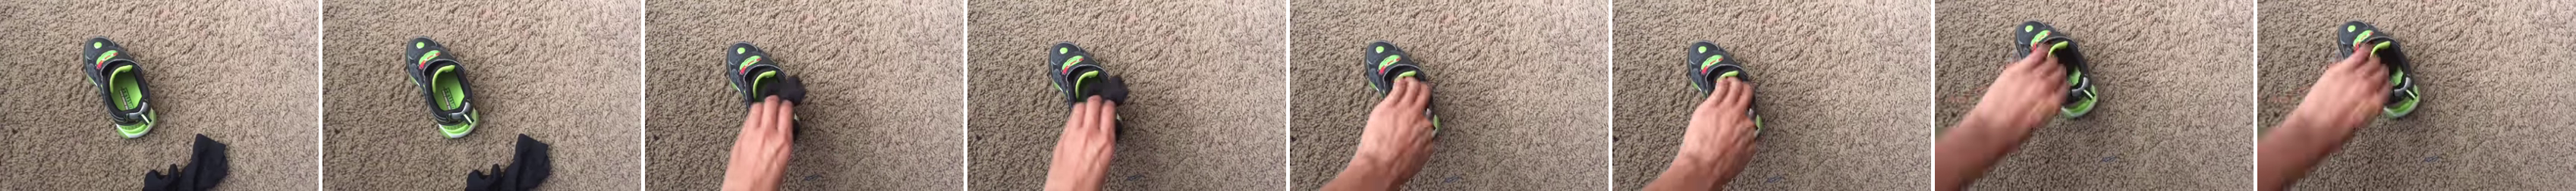

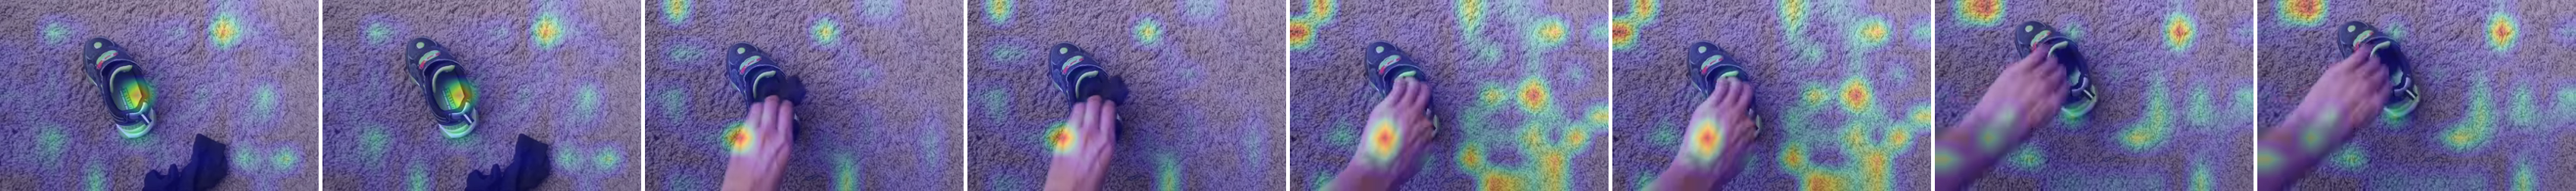

In [83]:
from IPython.display import display, Markdown
if suppress_sinks:
    title = f"No attention sinks ({model_name})"
else:
    title = f"With attention sinks ({model_name})"
display(Markdown(f"<div style='text-align: center;'><b>{title}</b></div>"))
display(su.visualize.concat_images_with_border(pil_frames))
display(su.visualize.concat_images_with_border(frame_with_heatmap))